# Eksperimen Model: CRNN (CNN + RNN/LSTM)
Kombinasi pamungkas untuk suara. CNN menangkap *Visual Pola Nada*, sedangkan LSTM mengingat *Urutan Waktu Nada* tersebut diucapkan. Ini adalah arsitektur yang sering dipakai di industri Voice Recognition.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Reshape, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print('Library Siap!')

Library Siap!


### 1. Memuat Matriks 2D

In [ ]:
X = np.load('X_features_2d_preprocessed.npy')
y = np.load('y_labels_preprocessed.npy')

X = X[..., np.newaxis]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Bentuk Data Latih (X_train) : {X_train.shape}")
print(f"Bentuk Data Uji (X_test)    : {X_test.shape}")

Bentuk Data Latih (X_train) : (2520, 40, 100, 1)
Bentuk Data Uji (X_test)    : (630, 40, 100, 1)


### 2. Membangun Arsitektur Hibrida (CRNN)

In [8]:
model_crnn = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2], 1)),
    
    # --- BLOK CNN (Mata AI) ---
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    BatchNormalization(),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    BatchNormalization(),
    
    # --- JEMBATAN KE LSTM ---
    # Setelah pooling 2 kali, dimensi berubah. Kita leburkan tinggi dan channel.
    # Bentuk akhir harus menjadi (TimeSteps, Features) agar bisa dibaca LSTM.
    Reshape((-1, 64)), # -1 akan otomatis menghitung TimeSteps yang tersisa
    
    # --- BLOK LSTM (Ingatan AI) ---
    LSTM(64, return_sequences=False),
    Dropout(0.4),
    
    # --- OUTPUT ---
    Dense(7, activation='softmax')
])

model_crnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_crnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 40, 100, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,679 (205.78 KB)

 Trainable params: 52,487 (205.03 KB)

 Non-trainable params: 192 (768.00 B)

### 3. Pelatihan Model

In [9]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_crnn = model_crnn.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 159ms/step - accuracy: 0.1657 - loss: 1.9387 - val_accuracy: 0.1687 - val_loss: 1.9068
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.2312 - loss: 1.8162 - val_accuracy: 0.1885 - val_loss: 1.9216
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.2698 - loss: 1.7660 - val_accuracy: 0.2222 - val_loss: 1.8012
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.2669 - loss: 1.7529 - val_accuracy: 0.2440 - val_loss: 1.7638
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.2798 - loss: 1.7324 - val_accuracy: 0.2341 - val_loss: 1.7607
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.2887 - loss: 1.7100 - val_accuracy: 0.2381 - val_loss: 1.7472
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.3239 - loss: 1.6742 - val_accuracy: 0.2659 - val_loss: 1.7208
Epoch 8/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.3046 - loss: 1.6537 - val_accuracy: 0

### 4. Evaluasi & Visualisasi

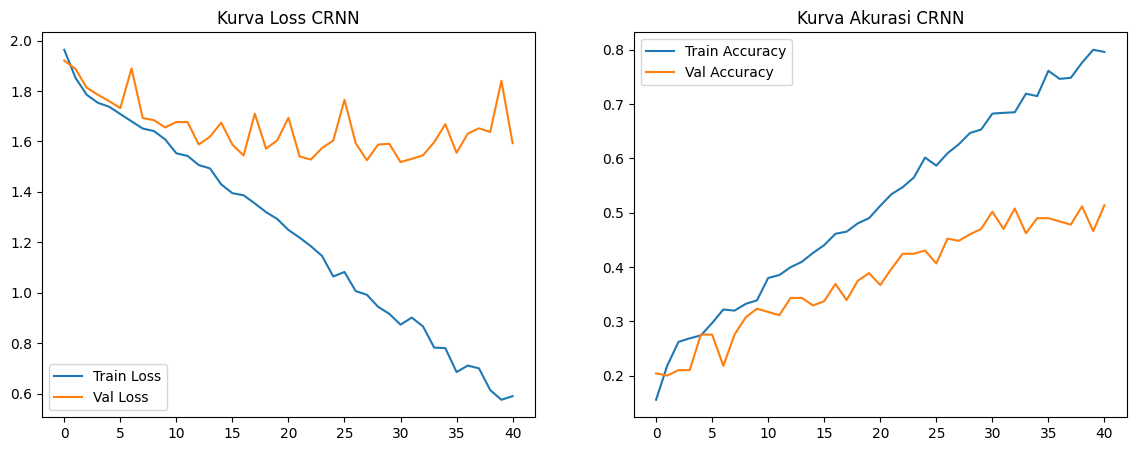

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step

Classification Report:
               precision    recall  f1-score   support

       horas       0.63      0.60      0.61        90
  sampurasun       0.51      0.67      0.58        90
adilkatalino       0.70      0.58      0.63        90
      wawawa       0.46      0.38      0.41        90
   kulanuwun       0.49      0.61      0.54        90
       tabea       0.33      0.27      0.30        90
     peuhaba       0.38      0.40      0.39        90

    accuracy                           0.50       630
   macro avg       0.50      0.50      0.50       630
weighted avg       0.50      0.50      0.50       630



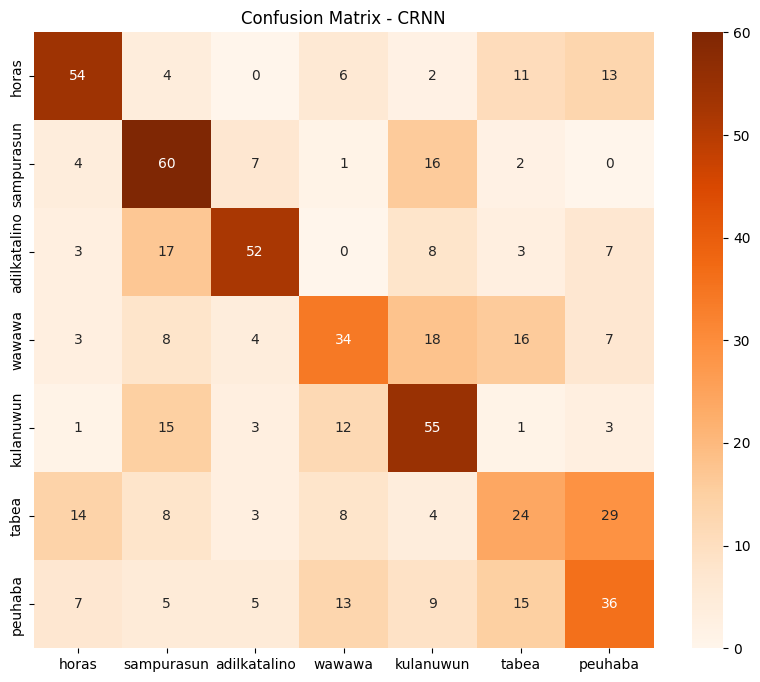

In [6]:
# A. Learning Curve
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_crnn.history['loss'], label='Train Loss')
plt.plot(history_crnn.history['val_loss'], label='Val Loss')
plt.title('Kurva Loss CRNN')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_crnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_crnn.history['val_accuracy'], label='Val Accuracy')
plt.title('Kurva Akurasi CRNN')
plt.legend()
plt.show()

# B. Confusion Matrix
y_pred_probs = model_crnn.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

classes = ['horas', 'sampurasun', 'adilkatalino', 'wawawa', 'kulanuwun', 'tabea', 'peuhaba']
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - CRNN')
plt.show()

### 5. Simpan Model

In [ ]:
import os
os.makedirs('models', exist_ok=True)
model_crnn.save('models/crnn_model.h5')
print('Model CRNN berhasil disimpan!')